# Ex. No: 07 
## Lane Detection using Hough Transform.

**Name :** PRASIDHA A    **Reg. No :** 212224230204    **Slot No :** T2-J6

In [49]:
# Import 
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [50]:
# Read Image
img = cv2.imread("lanee.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [51]:
# Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

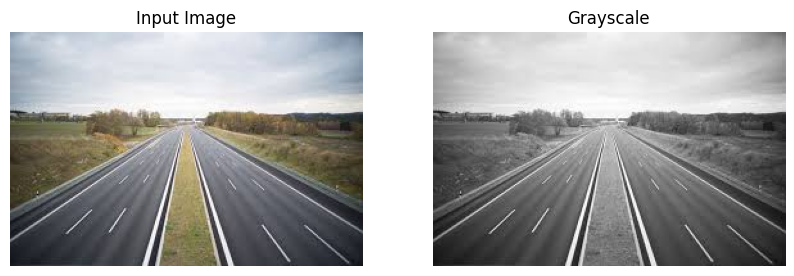

In [52]:
# Display Original and Grayscale
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.show()

In [53]:
edges = cv2.Canny(roi, 50, 150)

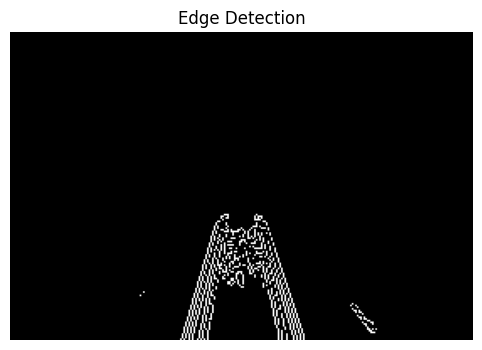

In [54]:
plt.figure(figsize=(6,4))
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")
plt.axis("off")
plt.show()

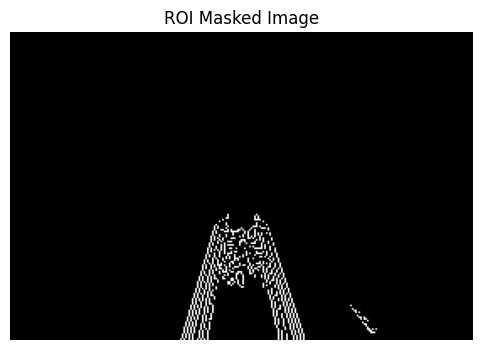

In [55]:
# Region of Interest
height, width = edges.shape

mask = np.zeros_like(edges)

polygon = np.array([[
    (50, height),
    (width-50, height),
    (width//2, int(height*0.55))
]], np.int32)

cv2.fillPoly(mask, polygon, 255)

roi = cv2.bitwise_and(edges, mask)

plt.figure(figsize=(6,4))
plt.imshow(roi, cmap='gray')
plt.title("ROI Masked Image")
plt.axis("off")
plt.show()

In [66]:
edges = cv2.Canny(roi, 100, 200)

canny_blur = cv2.GaussianBlur(edges, (5,5), 0)

In [70]:
lines = cv2.HoughLinesP(
    canny_blur,
    1,
    np.pi/180,
    threshold=30,
    minLineLength=20,
    maxLineGap=10
)

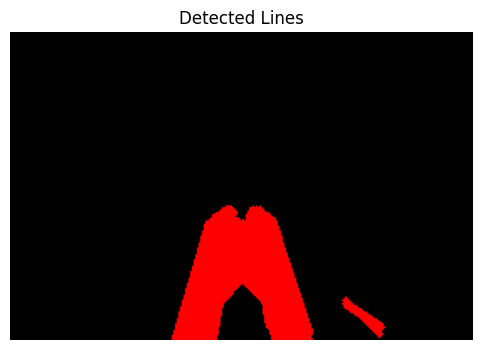

In [71]:
# Draw Detected Lines
line_image = np.zeros_like(img)

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_image, (x1,y1), (x2,y2), (255,0,0), 3)

plt.figure(figsize=(6,4))
plt.imshow(line_image)
plt.title("Detected Lines")
plt.axis("off")
plt.show()

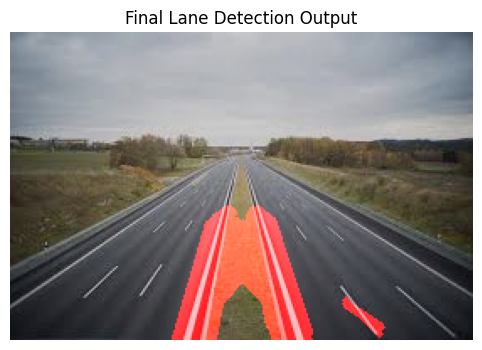

In [72]:
# Final Output
final_output = cv2.addWeighted(img, 0.8, line_image, 1, 0)

plt.figure(figsize=(6,4))
plt.imshow(final_output)
plt.title("Final Lane Detection Output")
plt.axis("off")
plt.show()